In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Load dataset
data = fetch_california_housing(as_frame=True)
df = data.frame

print(df.head())
print(df.shape) 

c:\Users\HYPE AMD\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\datasets\_base.py:1519: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976036
  warnings.warn(f"Retry downloading from url: {remote.url}")


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
(20640, 9)


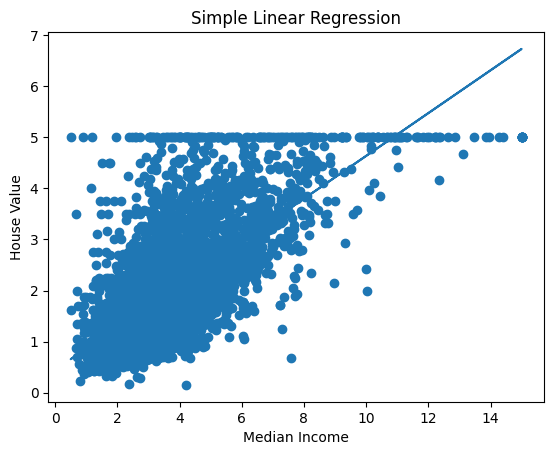

Simple Linear Regression
MAE: 0.63
RMSE: 0.842
R2: 0.459


In [13]:
# 1 fitur
X = df[["MedInc"]]
y = df["MedHouseVal"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

# Prediksi
y_pred = simple_model.predict(X_test)

# Visualisasi
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Simple Linear Regression")
plt.show()

# Evaluasi
print("Simple Linear Regression")
print("MAE:", round(mean_absolute_error(y_test, y_pred), 3))
print("RMSE:", round(root_mean_squared_error(y_test, y_pred), 3))
print("R2:", round(r2_score(y_test, y_pred), 3))

In [4]:
# 3 fitur
X_multi = df[["MedInc", "HouseAge", "AveRooms"]]
y = df["MedHouseVal"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# Model
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

# Prediksi
y_pred_multi = multi_model.predict(X_test)

# Evaluasi
print("Multiple Linear Regression")
print("MAE:", round(mean_absolute_error(y_test, y_pred_multi), 3))
print("RMSE:", round(root_mean_squared_error(y_test, y_pred_multi), 3))
print("R2:", round(r2_score(y_test, y_pred_multi), 3))

Multiple Linear Regression
MAE: 0.603
RMSE: 0.812
R2: 0.497


In [18]:
# Gunakan fitur MedInc
X_poly = df[["MedInc"]]
y = df["MedHouseVal"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# Degree 1
poly1 = PolynomialFeatures(degree=1, include_bias=False)
X_train_p1 = poly1.fit_transform(X_train)
X_test_p1 = poly1.transform(X_test)

model1 = LinearRegression()
model1.fit(X_train_p1, y_train)
pred1 = model1.predict(X_test_p1)

# Degree 2
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_p2 = poly2.fit_transform(X_train)
X_test_p2 = poly2.transform(X_test)

model2 = LinearRegression()
model2.fit(X_train_p2, y_train)
pred2 = model2.predict(X_test_p2)

In [20]:
# Degree 1
print("Polynomial Degree 1")
print("MAE:", round(mean_absolute_error(y_test, pred1), 3))
print("RMSE:", round(root_mean_squared_error(y_test, pred1), 3))
print("R2:", round(r2_score(y_test, pred1), 3))

# Degree 2
print("\nPolynomial Degree 2")
print("MAE:", round(mean_absolute_error(y_test, pred2), 3))
print("RMSE:", round(root_mean_squared_error(y_test, pred2), 3))
print("R2:", round(r2_score(y_test, pred2), 3))

Polynomial Degree 1
MAE: 0.63
RMSE: 0.842
R2: 0.459

Polynomial Degree 2
MAE: 0.628
RMSE: 0.839
R2: 0.463
